# Simulation of a silicon npn bipolar transistor
The graphs of the carrier concentrations and the output characteristics is stored in the folder fig.

In [1]:
import scipy.sparse as sparse 
from scipy.sparse.linalg import spsolve

import numpy as np

import matplotlib.pyplot as plt

from synumses.one_dimension.scharfetter_gummel_bernoulli import bernoulli, jacobian, update_b, first_jacobian, first_update_b, hole_current_density, electron_current_density

import synumses.one_dimension.parameters as parameters

from synumses.one_dimension.functions import  ohm_potential, calc_p_density, calc_n_density, calc_recombination


import synumses.one_dimension.solver as solver

{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

## Definition of the transistor

In [2]:
parameters.n = 600
parameters.lx = 1200E-9

parameters.init_geometry()

#parameters.Cau = 0*1E-24  

Nd_Emitter   = 1.2E24
Na_Base      = 4.0E22
Nd_Collector = 2.0E22

Eg = 1.12

# np transition at x1
# pn transition at x2

x1 = 400E-9
x2 = 800E-9

for i in range(0, parameters.n):
    
    parameters.Ec[i] = Eg
    parameters.Ev[i] = 0
    
    if parameters.pos_x[i] < x1:
        
        parameters.C[i] = + Nd_Emitter
    elif parameters.pos_x[i] < x2: 
        parameters.C[i] = - Na_Base
    else:
        parameters.C[i] = + Nd_Collector

Now, we plot the default band diagramm and the doping levels

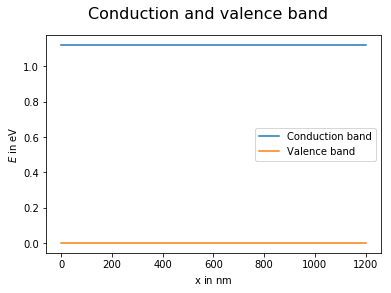

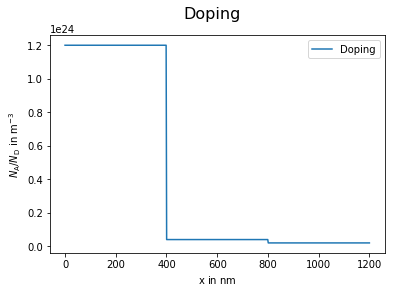

In [3]:
#
# Plot band diagramm and doping
#
fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Conduction and valence band", fontsize=16)

axis.plot(parameters.pos_x * 1E9, parameters.Ec, label='Conduction band')
axis.plot(parameters.pos_x * 1E9, parameters.Ev, label='Valence band')

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$E$ in $\mathrm{eV}$")

axis.legend()
plt.show()

# Doping level
fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Doping", fontsize=16)

#axis.semilogy(np.abs(parameters.C), label='Doping')
axis.plot(parameters.pos_x * 1E9, np.abs(parameters.C), label='Doping')

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$N_\mathrm{A} / N_\mathrm{D}$ in $\mathrm{m^{-3}}$")

axis.legend()
plt.show()


The following function calculates the potential according the doping and band structure.

In [4]:
parameters.init_potential()

Now, we plot the potential according the doping and band structure.

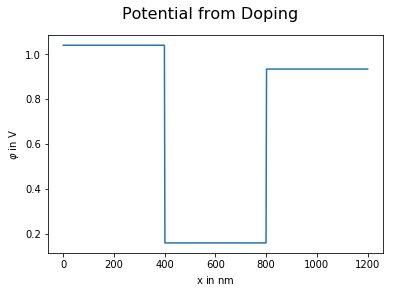

In [5]:
fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Potential from Doping", fontsize=16)

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$\varphi$ in $\mathrm{V}$")

axis.plot(parameters.pos_x * 1E9, parameters.u[0::3])
plt.show()

Now, let's plot the band diagramm considering diffusion but no biasing.<br>
This must be done before simulating with bias.

/home/pabele/anaconda3/lib/python3.7/site-packages/scipy/sparse/linalg/dsolve/linsolve.py:133: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  SparseEfficiencyWarning)


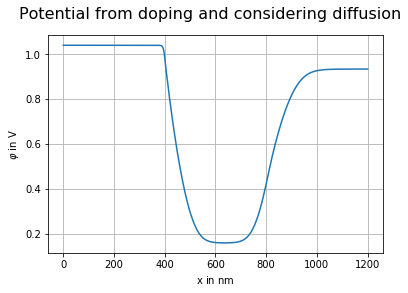

In [6]:
solver.solve_no_bias()

fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Potential from doping and considering diffusion", fontsize=16)

axis.plot(parameters.pos_x * 1E9, parameters.u[0::3])

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$\varphi$ in $\mathrm{V}$")

axis.grid()
plt.show()

Now, let's ramp $U_\mathrm{BE}$ to $0.6\,\mathrm{V}$.

Spannung 0.0
Norm:  0.0032784904064531006
Norm:  9.362152246311067e-06
Norm:  1.3153155524609986e-10
Norm:  1.566379414734165e-12
Norm:  1.566562720261561e-12
Spannung 0.05
Norm:  1.155956799405361
Norm:  0.17616308033071032
Norm:  0.030370387206399542
Norm:  0.001472958585681479
Norm:  3.825730899332373e-06
Norm:  3.090528406210079e-11
Norm:  2.6924753392531984e-12
Norm:  4.4155552464667557e-13
Norm:  1.4951738303175225e-12
Spannung 0.1
Norm:  1.2653416099740882
Norm:  0.11715121118774519
Norm:  0.018762865447950472
Norm:  0.0008625768332740396
Norm:  2.186235724951215e-06
Norm:  1.7584763053954648e-11
Norm:  6.436625335061783e-13
Norm:  7.718262861001122e-13
Spannung 0.15000000000000002
Norm:  1.3328645362894798
Norm:  0.05529875024190104
Norm:  0.008175292775785811
Norm:  0.00036372074817257467
Norm:  9.062000825274089e-07
Norm:  7.25439524796689e-12
Norm:  1.2386920449021643e-12
Norm:  1.299093742170514e-12
Spannung 0.2
Norm:  1.3576815621463918
Norm:  0.01888448699687917
Norm:  0.

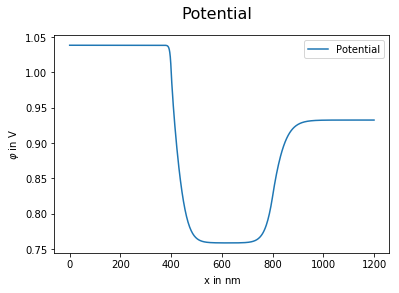

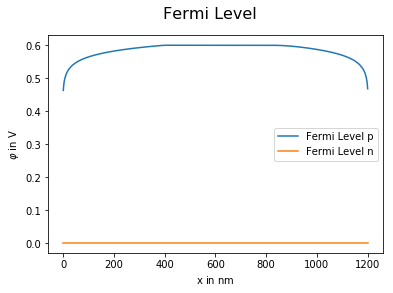

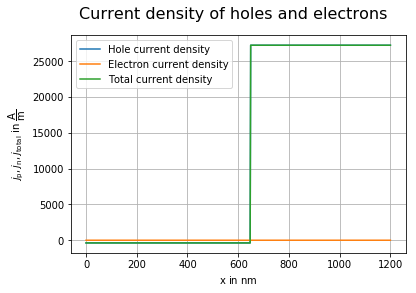

In [8]:
solver.solve_no_bias()

u_start = .00
u_stop  = .6
u_step  = 0.05


while (u_start <= u_stop):
    print("Spannung", u_start)
    solver.solve_bias_center_boundary(.0 , 0, u_start, 650E-9, "p")
    u_start += u_step
    

    
    
# Potential
fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Potential", fontsize=16)

axis.plot(parameters.pos_x * 1E9, parameters.u[0::3], label='Potential')

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$\varphi$ in $\mathrm{V}$")

#plt.ylim((0.95,0.96))
axis.legend()
plt.show()

# Fermi-Level
fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Fermi Level", fontsize=16)

axis.plot(parameters.pos_x * 1E9, parameters.u[1::3], label='Fermi Level p')
axis.plot(parameters.pos_x * 1E9, parameters.u[2::3], label='Fermi Level n')

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$\varphi$ in $\mathrm{V}$")

axis.legend()
plt.show() 
    
    
# Hole and electron current density 
j_p =     hole_current_density()
j_n =     electron_current_density()

fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Current density of holes and electrons", fontsize=16)

axis.plot(parameters.pos_x * 1E9, j_p, label='Hole current density')
axis.plot(parameters.pos_x * 1E9, j_n, label='Electron current density')
axis.plot(parameters.pos_x * 1E9, j_n+j_p, label='Total current density')

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$j_\mathrm{p}, j_\mathrm{n}, j_\mathrm{total}$ in $\mathrm{\dfrac{A}{m}}$")

axis.legend()
axis.grid()
plt.show()
 

Now, let's ramp $U_\mathrm{CE}$ to $3\,\mathrm{V}$.

Spannung 0.0
Norm:  2.067537877593826e-12
Norm:  7.359773205227825e-13
Norm:  2.059821253310334e-12
Spannung 0.05
Norm:  1.0499171932084093
Norm:  0.5225693813443739
Norm:  0.0418260096317207
Norm:  0.031460912381951124
Norm:  0.02743779302264528
Norm:  0.02595697494222749
Norm:  0.02587503016513835
Norm:  0.025874668057354017
Norm:  0.025874097695352906
Norm:  0.025872547367207812
Norm:  0.02586833368475936
Norm:  0.02585688374441031
Norm:  0.025825789378273883
Norm:  0.025741485828043486
Norm:  0.025513938732073728
Norm:  0.024907134043965346
Norm:  0.0233406609431748
Norm:  0.019628711763542923
Norm:  0.012537428716060034
Norm:  0.004222449162426366
Norm:  0.0003844011873821985
Norm:  2.8837860971685376e-06
Norm:  1.6072934321003895e-10
Norm:  2.0234658483746277e-12
Norm:  3.8506975306930305e-12
Spannung 0.1
Norm:  1.0088342996369328
Norm:  0.5275282743203373
Norm:  0.03924951287514503
Norm:  0.03170037784933127
Norm:  0.02757629028616929
Norm:  0.025972490762553153
Norm:  0.0258751

/home/pabele/anaconda3/lib/python3.7/site-packages/matplotlib/pyplot.py:514: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  max_open_warning, RuntimeWarning)


Spannung 1.0500000000000003
Norm:  1.0411247863367301
Norm:  0.013508330351574064
Norm:  0.000818593990551683
Norm:  4.536778586647278e-06
Norm:  1.7019109138122679e-10
Norm:  1.687648702605043e-12
Norm:  1.0927391236495054e-12
Norm:  2.3971143845413036e-12
Spannung 1.1000000000000003
Norm:  1.0380793868108111
Norm:  0.012278312007995751
Norm:  0.0006797093551826482
Norm:  3.2258501734332644e-06
Norm:  8.924794764810087e-11
Norm:  2.7931332433512916e-12
Norm:  1.5503668795649117e-12
Norm:  1.7683330134150212e-12
Spannung 1.1500000000000004
Norm:  1.0348323147277345
Norm:  0.011292380456386131
Norm:  0.0005744955360576335
Norm:  2.3658421623543996e-06
Norm:  4.951106477081291e-11
Norm:  1.7599270699321242e-12
Norm:  6.481547099437446e-13
Norm:  1.7255777509548683e-12
Spannung 1.2000000000000004
Norm:  1.0314471584902876
Norm:  0.010486709326231176
Norm:  0.0004928127205213093
Norm:  1.780899078575014e-06
Norm:  2.879415210121066e-11
Norm:  9.162349472789008e-13
Norm:  1.250714370174636e

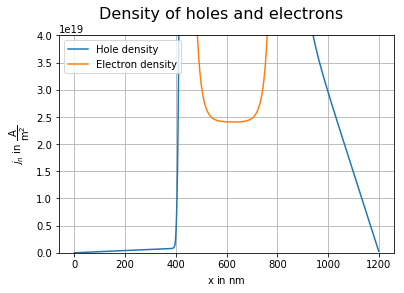

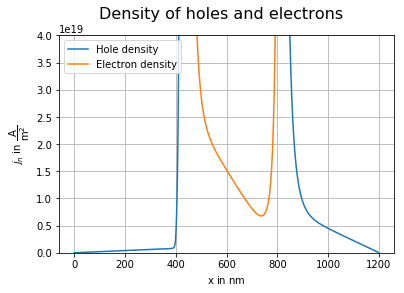

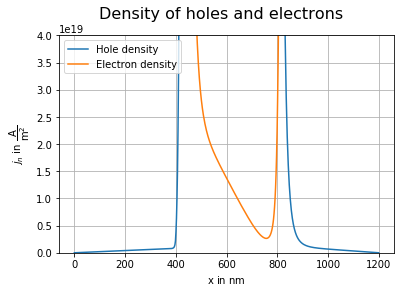

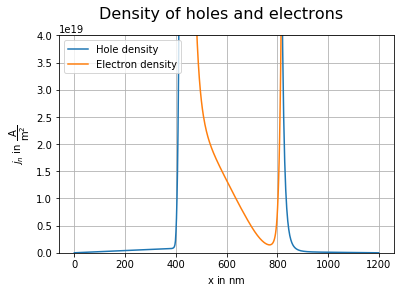

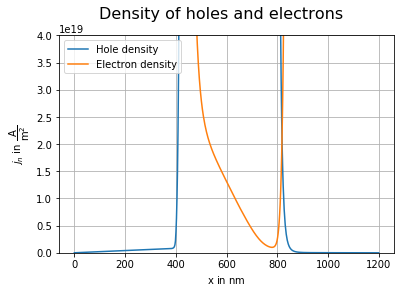

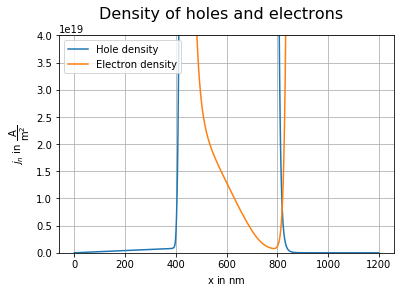

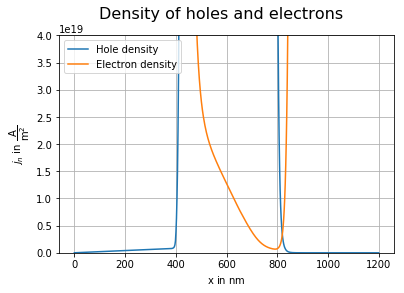

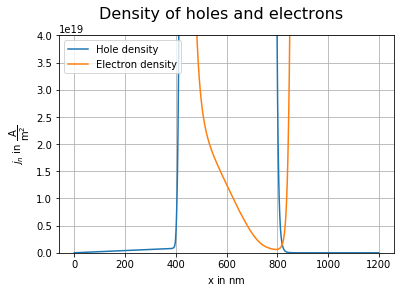

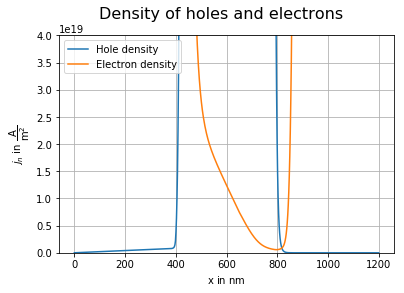

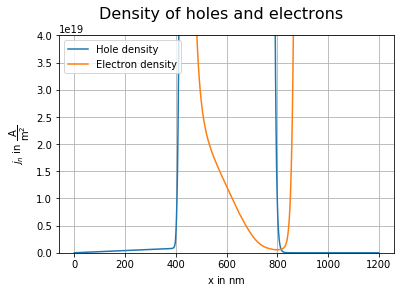

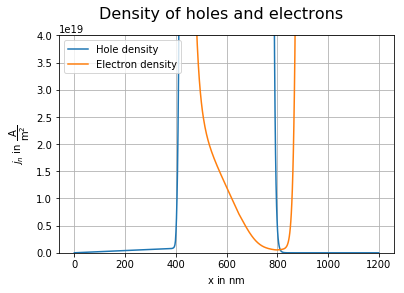

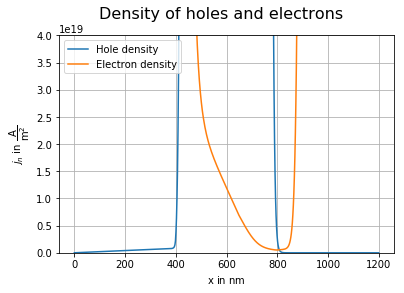

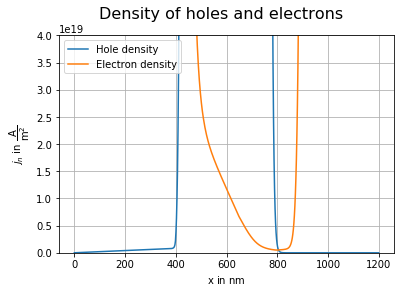

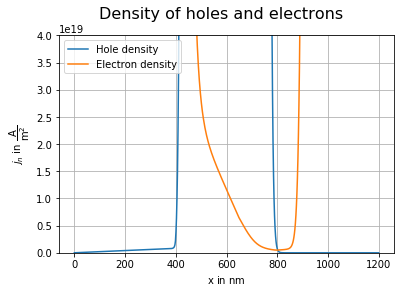

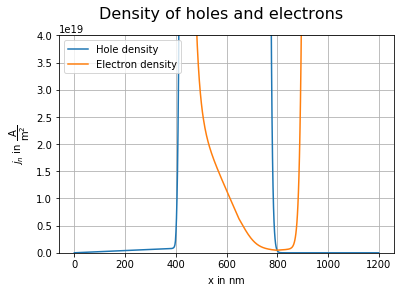

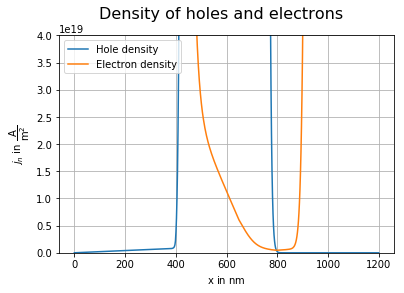

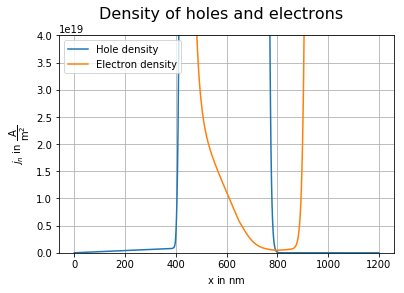

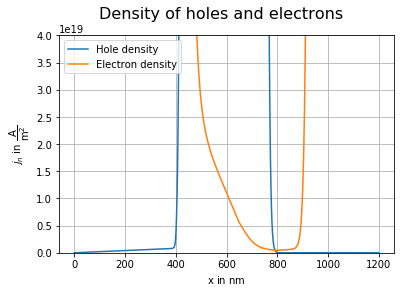

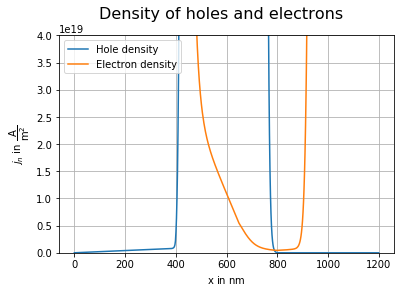

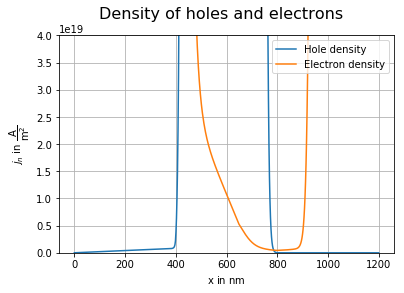

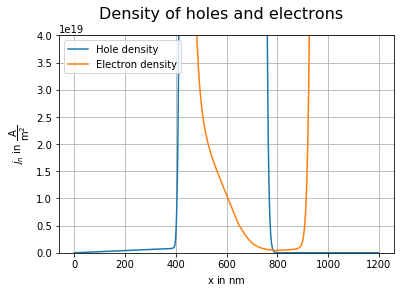

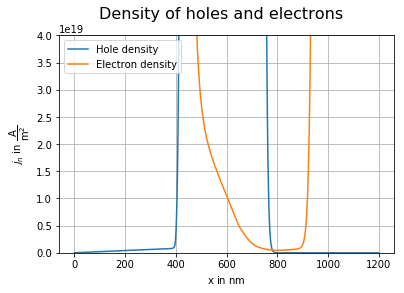

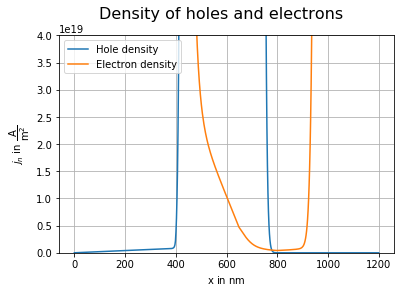

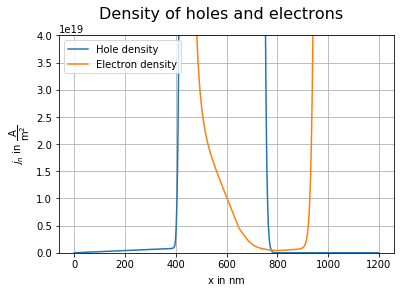

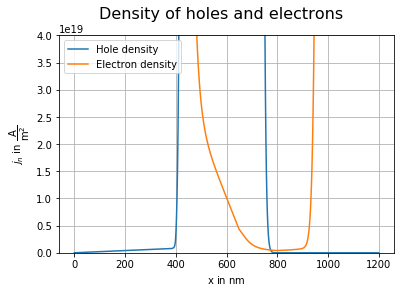

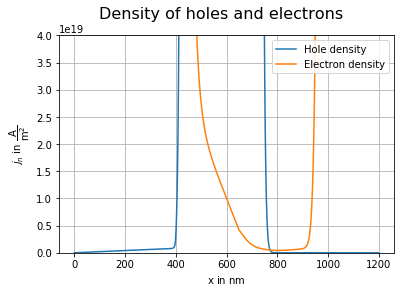

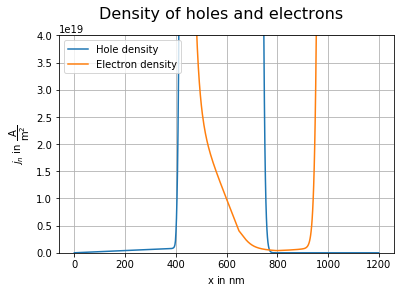

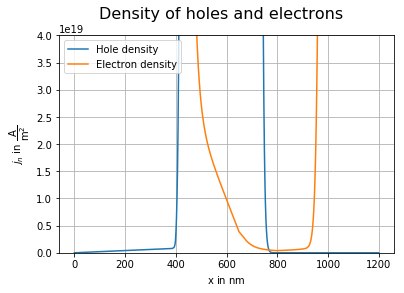

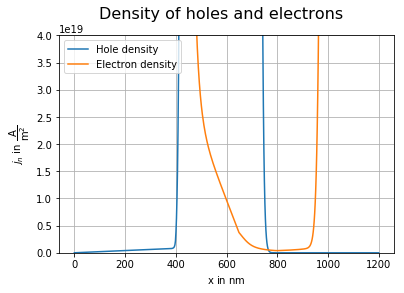

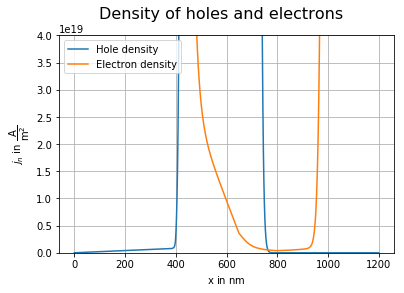

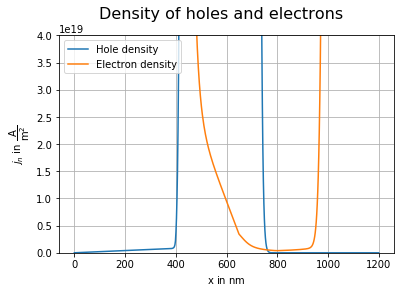

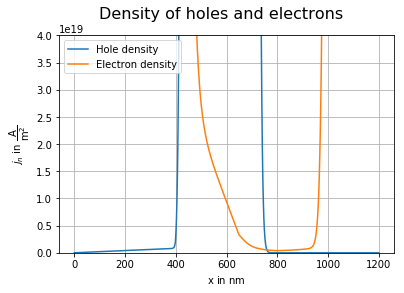

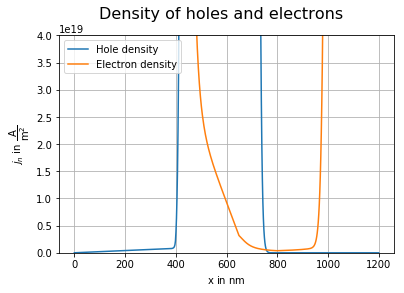

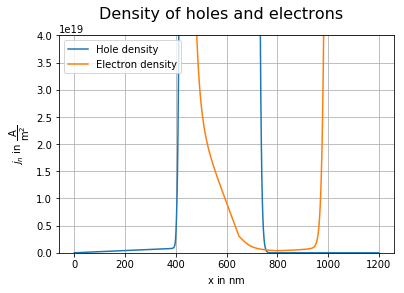

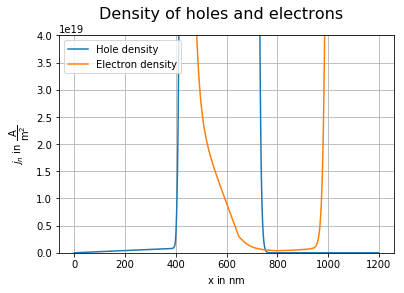

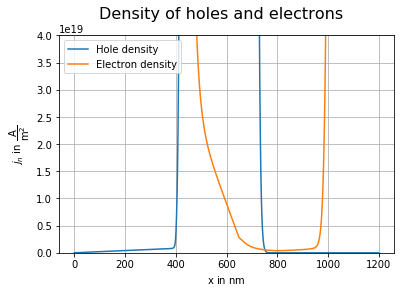

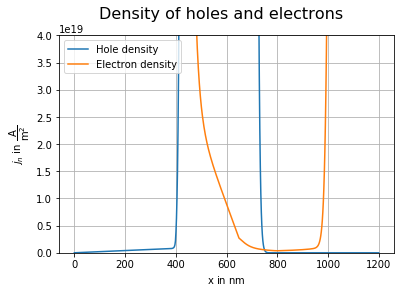

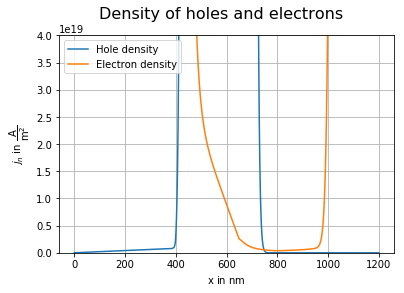

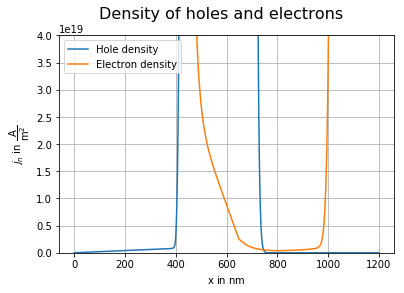

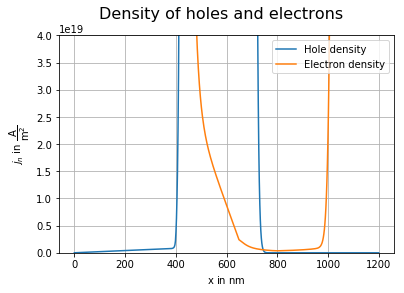

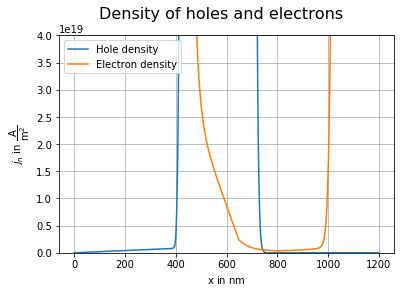

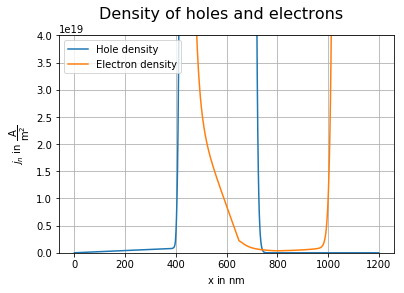

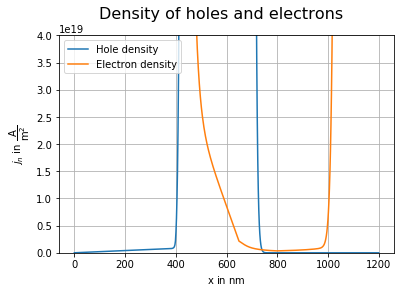

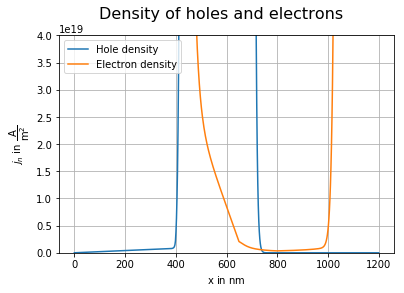

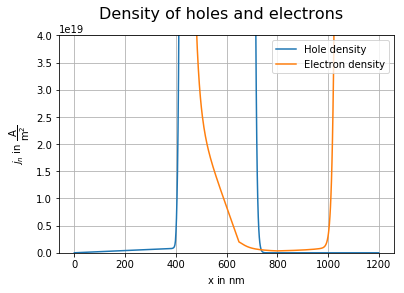

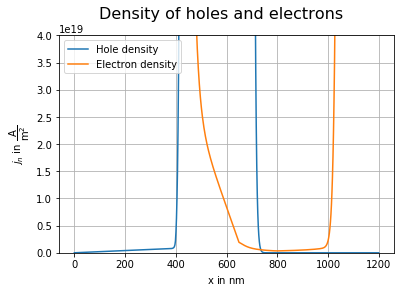

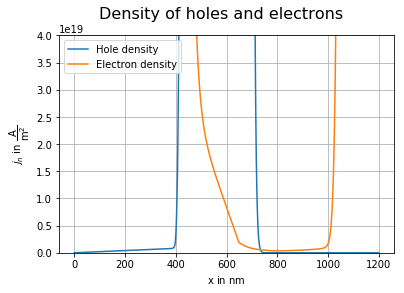

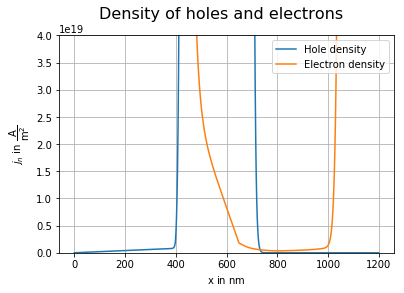

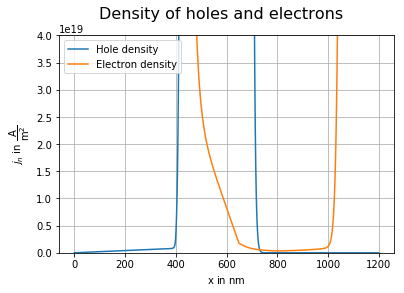

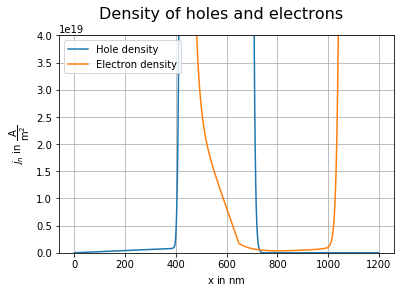

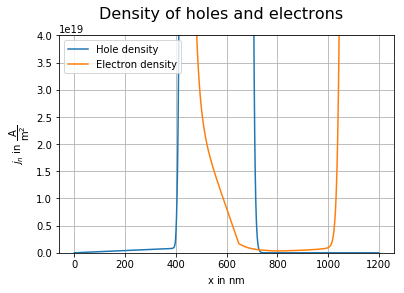

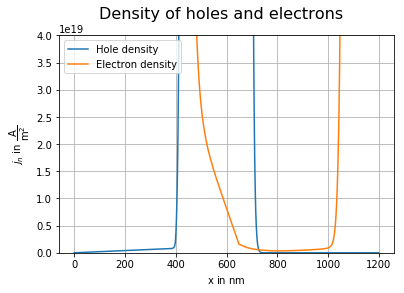

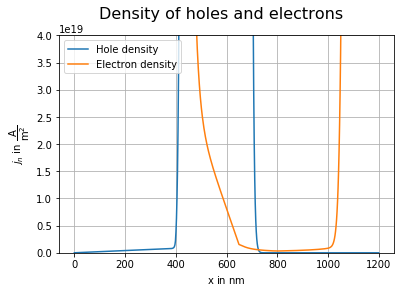

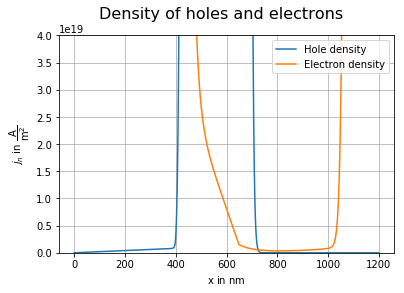

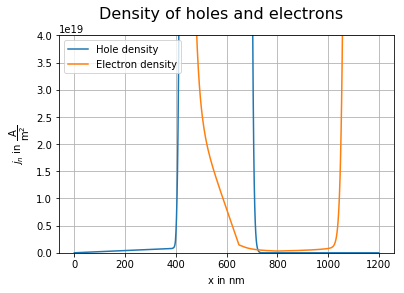

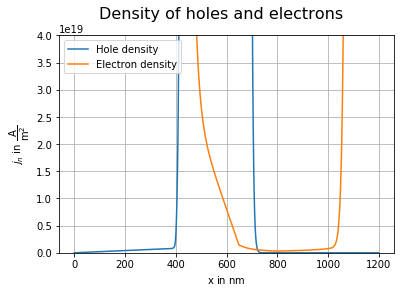

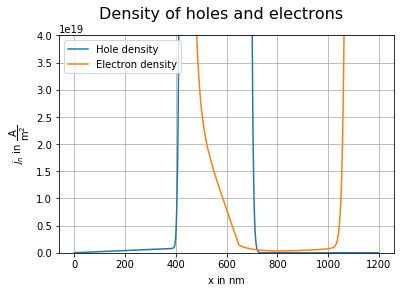

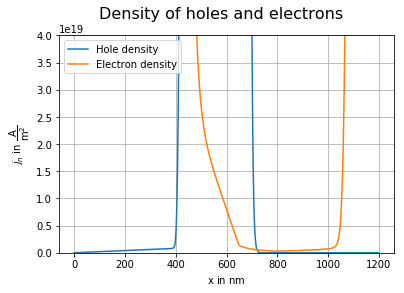

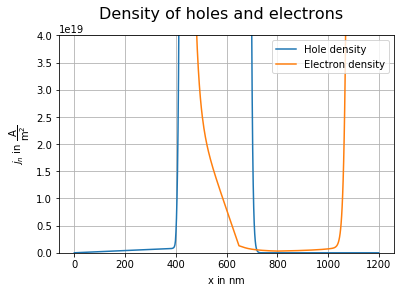

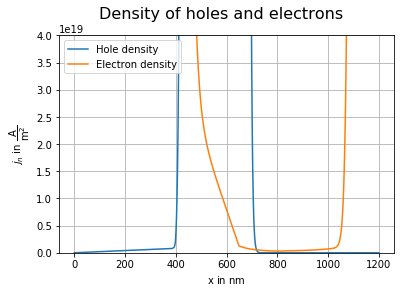

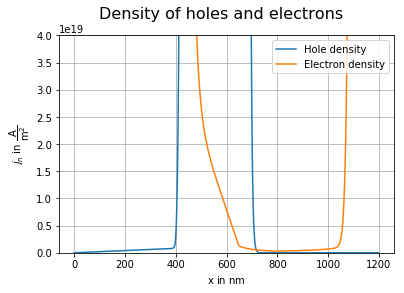

In [9]:
base_current = []
collector_current = []
collector_voltage = []

u_base = 0.6

u_start = 0.0
u_stop  = 3.0
u_step  = 0.05


while (u_start <= u_stop):
    print("Spannung", u_start)
    solver.solve_bias_center_boundary(.0 , u_start, u_base, 650E-9, "p")
    
    j_p =     hole_current_density()
    j_n =     electron_current_density()
    
    base_current.append(-j_p[0])
    collector_current.append(-j_n[0])
    collector_voltage.append(u_start)
    
    u_start += u_step
    
    # Hole and electron density
    calc_p_density()
    calc_n_density()

    p = parameters.p_density
    n = parameters.n_density

    fig, axis = plt.subplots(1,1, sharey=True)
    fig.suptitle("Density of holes and electrons", fontsize=16)

    axis.plot(parameters.pos_x * 1E9, p, label='Hole density')
    axis.plot(parameters.pos_x * 1E9, n, label='Electron density')

    plt.ylim((0,.4E20))

    axis.set_xlabel(r"x in $\mathrm{nm}$")
    axis.set_ylabel(r"$j_n$ in $\mathrm{\dfrac{A}{m^2}}$")

    axis.grid()
    axis.legend()
    figname = './fig/carrier_concentration_{:0>4}.png'.format(str(round((u_start*1000.0))))
    plt.savefig(figname)
    plot.close()
    

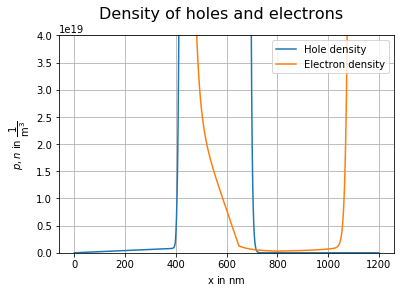

In [10]:

# Hole and electron density
calc_p_density()
calc_n_density()

p = parameters.p_density
n = parameters.n_density

fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Density of holes and electrons", fontsize=16)

axis.plot(parameters.pos_x * 1E9, p, label='Hole density')
axis.plot(parameters.pos_x * 1E9, n, label='Electron density')

plt.ylim((0,.4E20))

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$p, n$ in $\mathrm{\dfrac{1}{m^3}}$")

axis.grid()
axis.legend()
plt.show()




Ramp up the voltage to determine the power density.

Plot the current density and the power density.

In [11]:
print(j_p[0], j_n[0], j_n[599])
print(j_n[599] / j_p[0])

-375.1438766823633 -79087.86581814685 -79087.86600776631
210.82009043354452


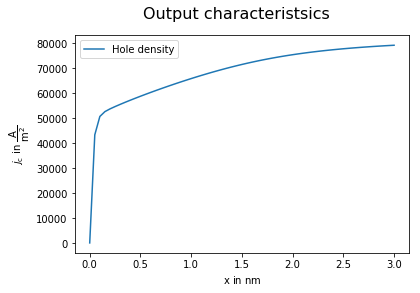

In [13]:
# Collector current density 

fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Output characteristsics", fontsize=16)

axis.plot(collector_voltage,collector_current, label='Hole density')

#plt.ylim((0,.2E20))

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$j_\mathrm{c}$ in $\mathrm{\dfrac{A}{m^2}}$")

axis.legend()
plt.show()

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60


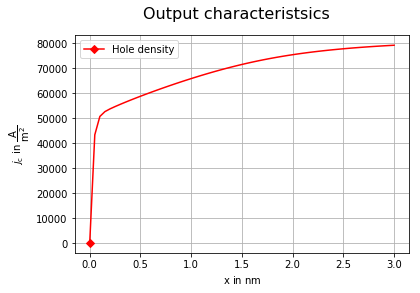

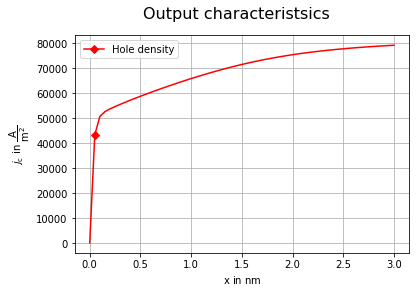

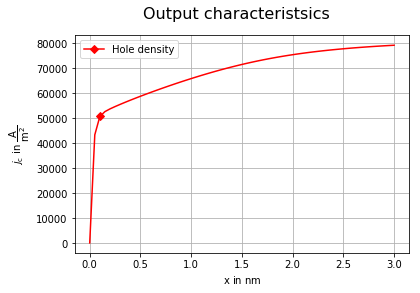

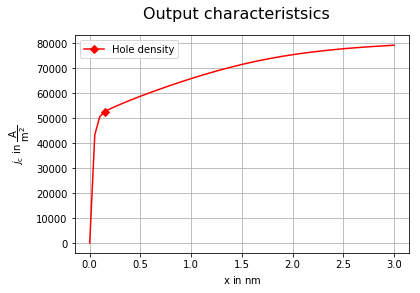

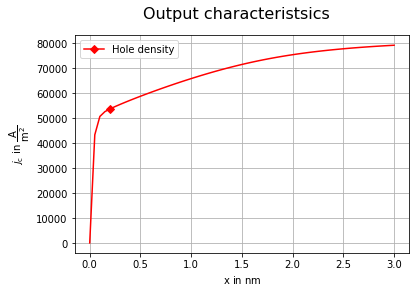

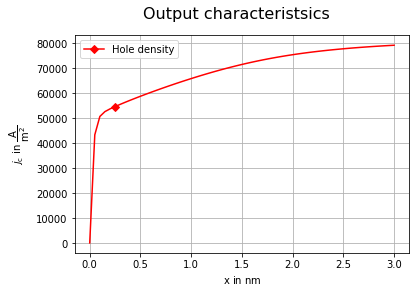

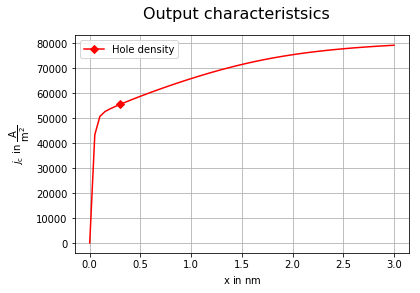

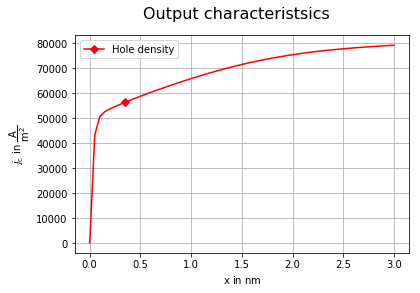

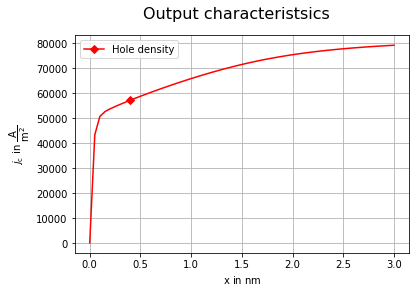

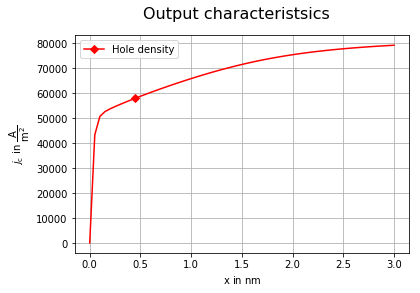

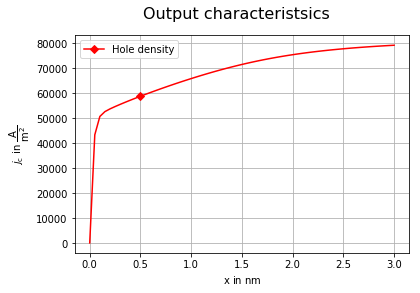

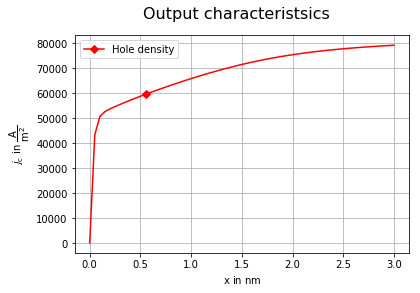

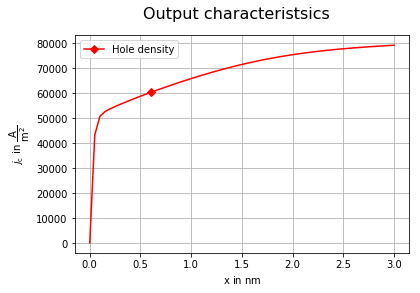

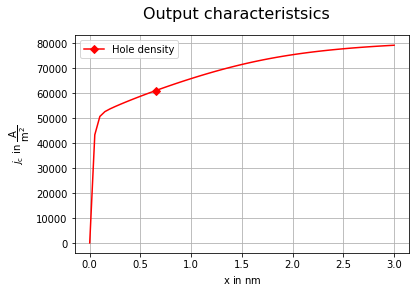

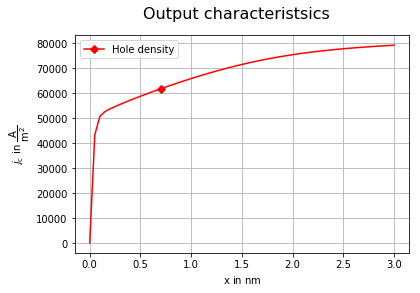

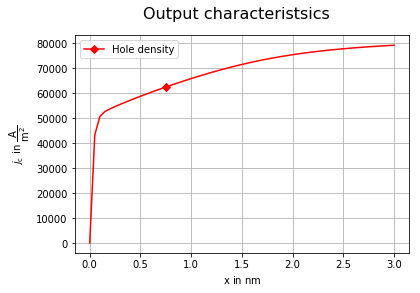

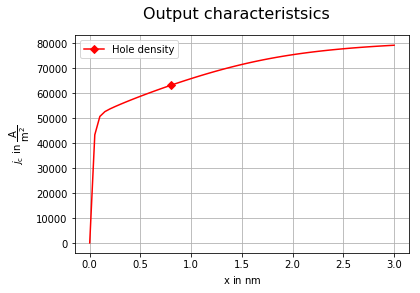

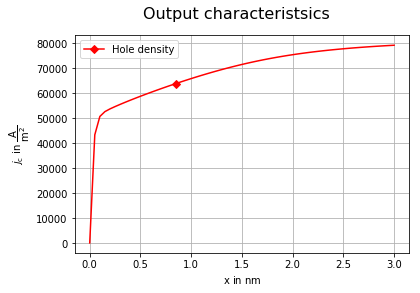

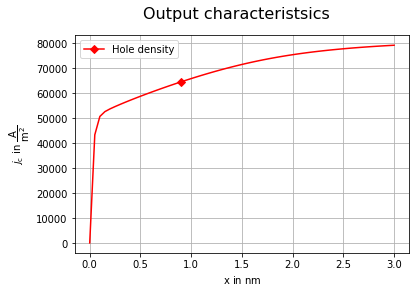

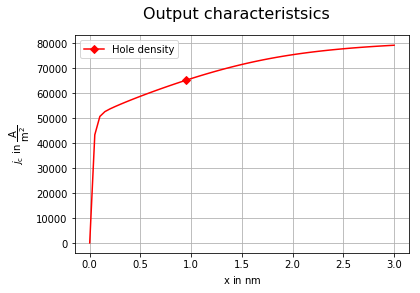

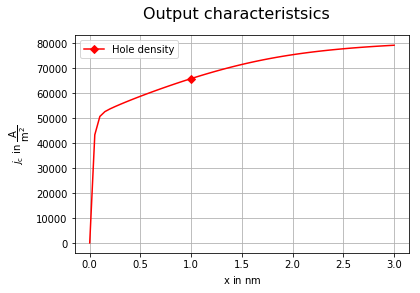

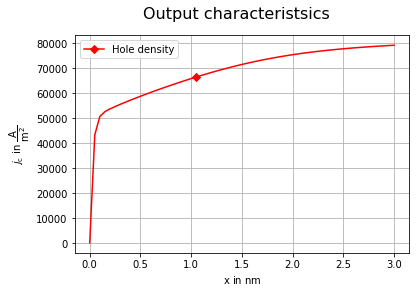

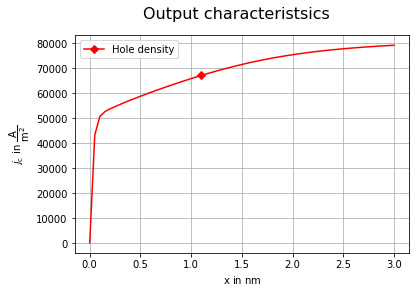

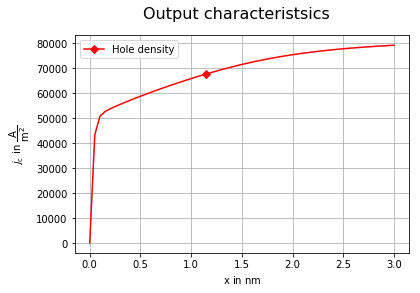

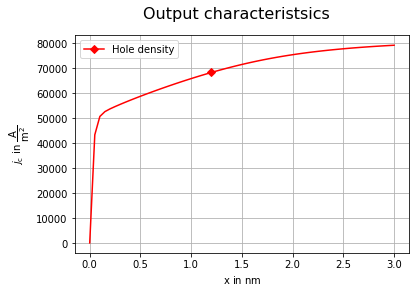

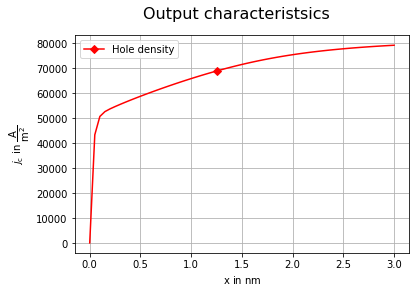

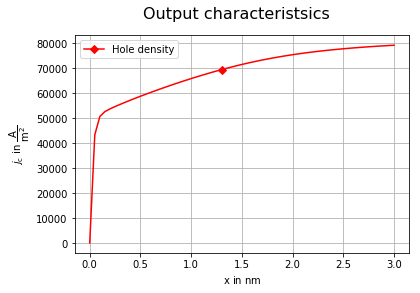

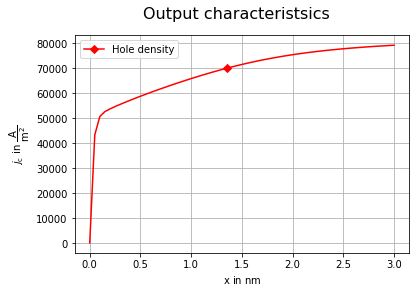

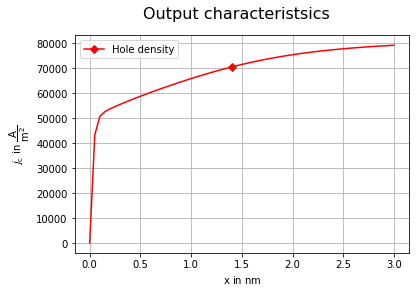

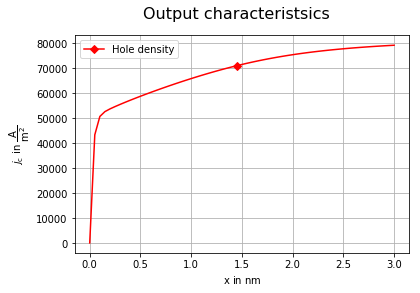

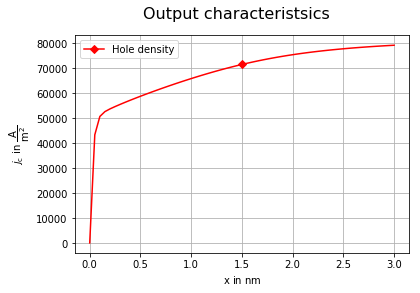

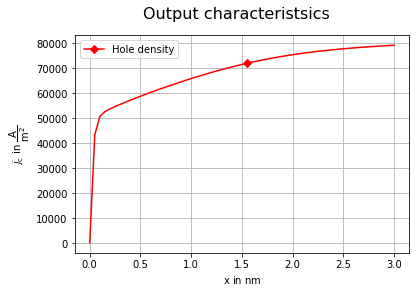

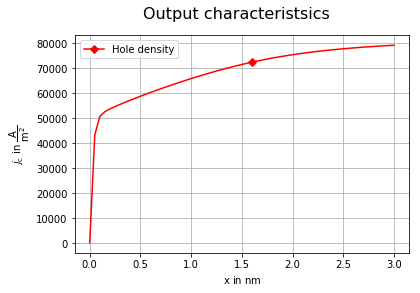

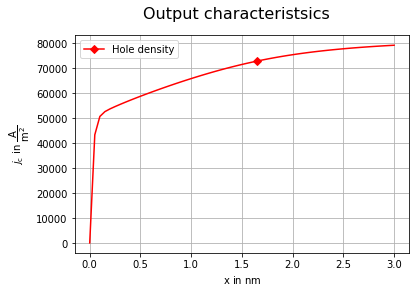

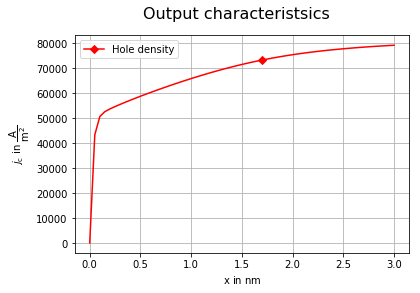

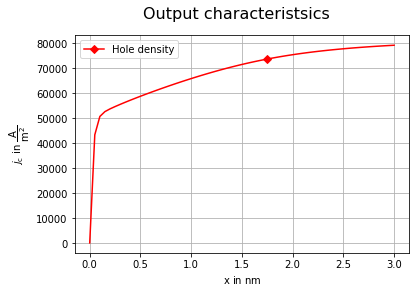

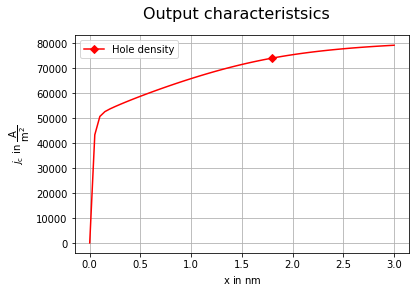

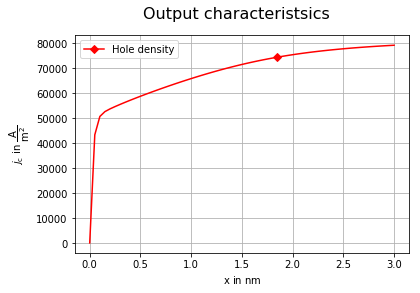

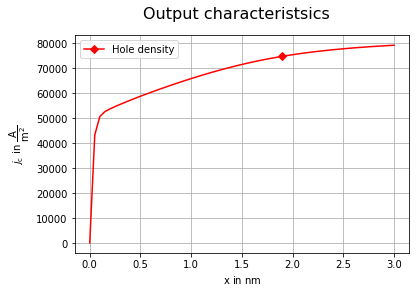

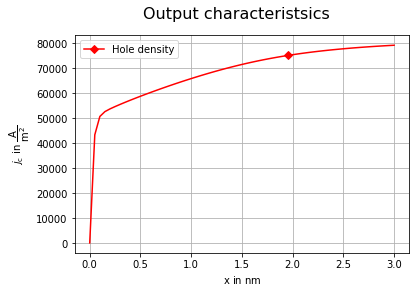

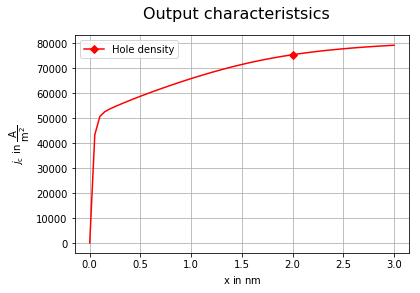

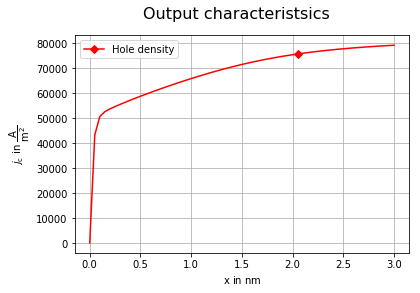

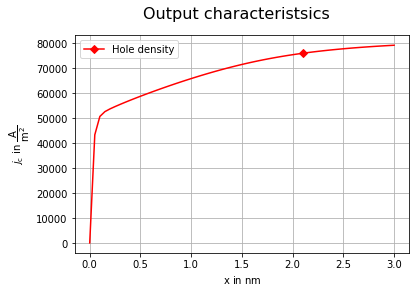

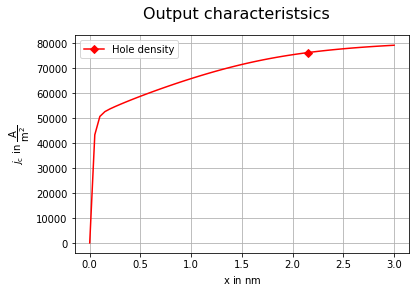

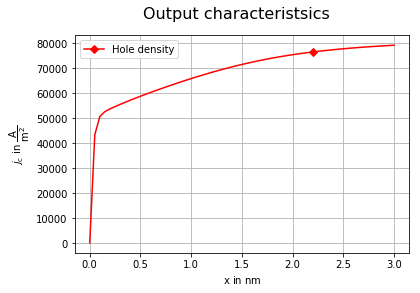

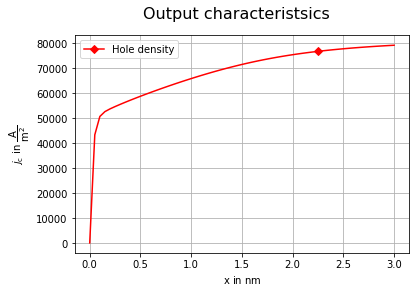

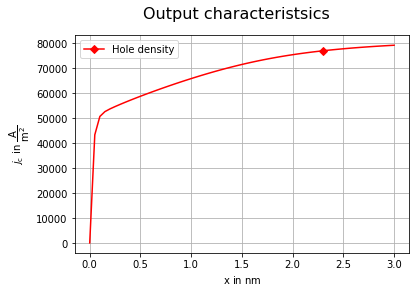

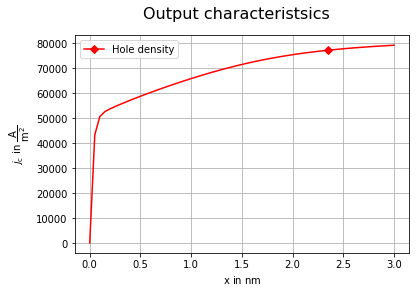

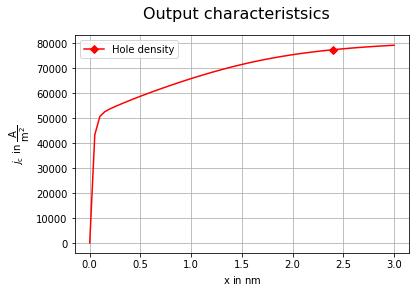

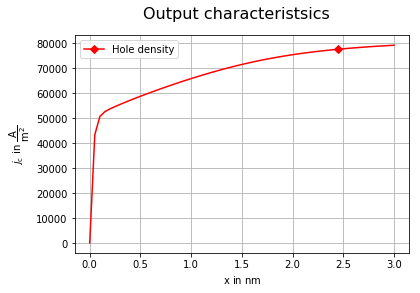

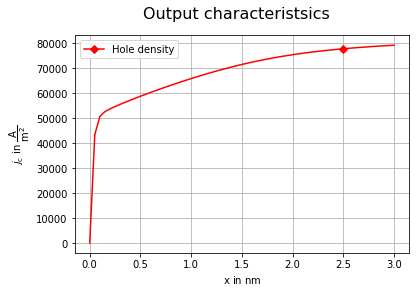

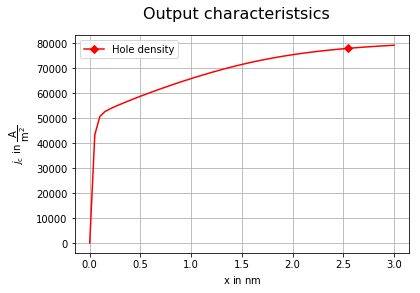

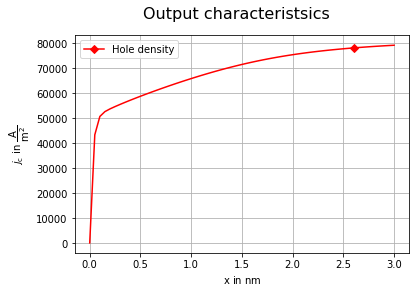

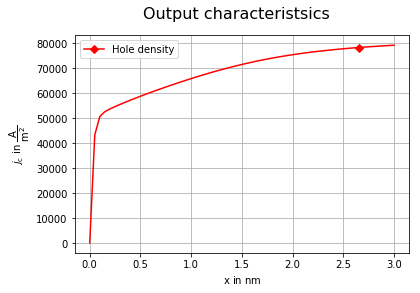

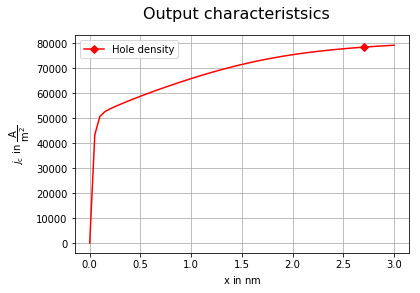

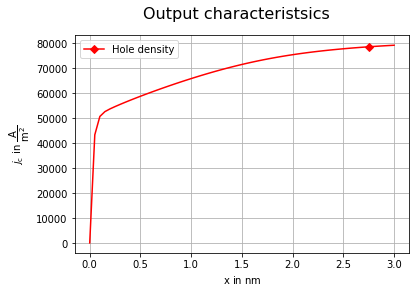

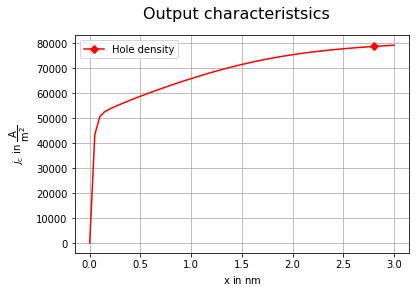

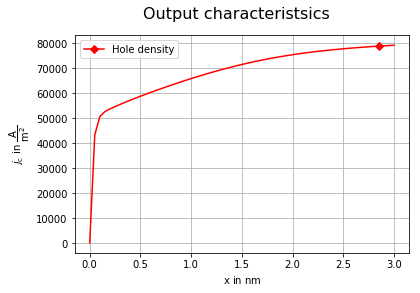

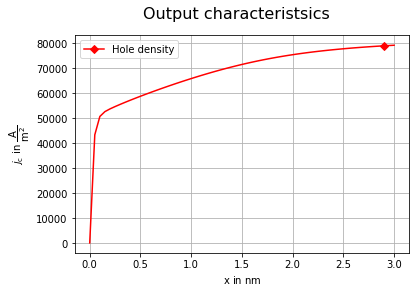

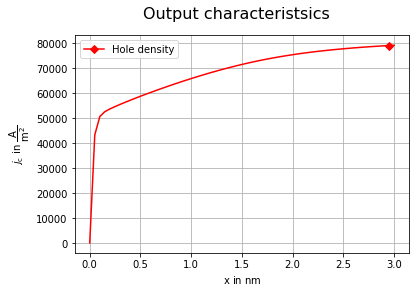

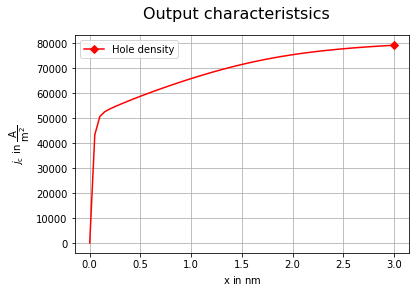

In [16]:
for bias in collector_voltage:
    fig, axis = plt.subplots(1,1, sharey=True)
    fig.suptitle("Output characteristsics", fontsize=16)

    idx = np.abs(np.subtract(collector_voltage, bias)).argmin()
    print(idx)
    axis.plot(collector_voltage,
              collector_current,
              '-rD', markevery=[idx],
              label='Hole density')

    #plt.ylim((0,.2E20))

    axis.set_xlabel(r"x in $\mathrm{nm}$")
    axis.set_ylabel(r"$j_\mathrm{c}$ in $\mathrm{\dfrac{A}{m^2}}$")

    
    axis.grid()
    axis.legend()
    
    figname = './fig/output_characteristsics_{:0>4}.png'.format(str(round((bias*1000.0))))
    plt.savefig(figname)
    #plt.close()

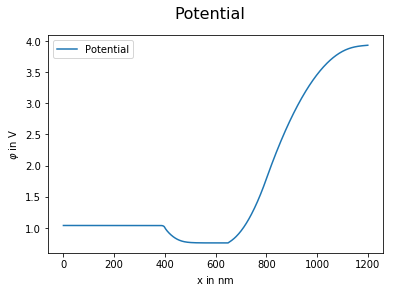

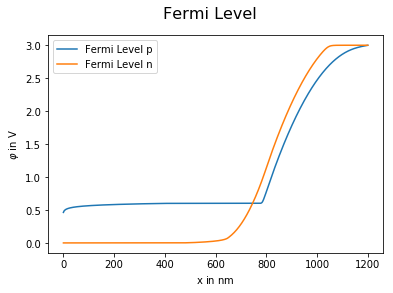

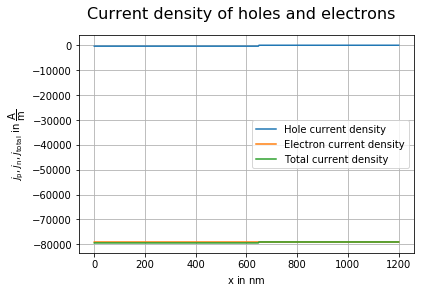

In [17]:
# Potential
fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Potential", fontsize=16)

axis.plot(parameters.pos_x * 1E9, parameters.u[0::3], label='Potential')

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$\varphi$ in $\mathrm{V}$")

#plt.ylim((0.95,0.96))
axis.legend()
plt.show()

# Fermi-Level
fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Fermi Level", fontsize=16)

axis.plot(parameters.pos_x * 1E9, parameters.u[1::3], label='Fermi Level p')
axis.plot(parameters.pos_x * 1E9, parameters.u[2::3], label='Fermi Level n')

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$\varphi$ in $\mathrm{V}$")

axis.legend()
plt.show() 
    
    
# Hole and electron current density 
j_p =     hole_current_density()
j_n =     electron_current_density()

fig, axis = plt.subplots(1,1, sharey=True)
fig.suptitle("Current density of holes and electrons", fontsize=16)

axis.plot(parameters.pos_x * 1E9, j_p, label='Hole current density')
axis.plot(parameters.pos_x * 1E9, j_n, label='Electron current density')
axis.plot(parameters.pos_x * 1E9, j_n+j_p, label='Total current density')

axis.set_xlabel(r"x in $\mathrm{nm}$")
axis.set_ylabel(r"$j_\mathrm{p}, j_\mathrm{n}, j_\mathrm{total}$ in $\mathrm{\dfrac{A}{m^2}}$")

axis.legend()
axis.grid()
plt.show()